In [7]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from ipywidgets import interact, FloatSlider

# --- ПАРАМЕТРЫ ---
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
BATCH_SIZE = 128
LATENT_DIM = 32
FC_WEIGHTS = 'fc_autoencoder_weights.pth'
CONV_WEIGHTS = 'conv_autoencoder_weights.pth'

# --- МОДЕЛИ ---

class FCAutoEncoder(nn.Module):
    def __init__(self, img_shape=(1, 28, 28), latent_dim=32):
        super(FCAutoEncoder, self).__init__()
        self.img_shape = img_shape
        inp_dim = img_shape[1] * img_shape[2]
        self.encoder = nn.Sequential(
            nn.Linear(inp_dim, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, inp_dim), nn.Sigmoid()
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.decoder(self.encoder(x)).view(-1, *self.img_shape)

class ConvAutoEncoder(nn.Module):
    def __init__(self, img_shape=(1, 28, 28), latent_dim=32):
        super(ConvAutoEncoder, self).__init__()
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU()
        )
        self.fc_encode = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 128 * 4 * 4)
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=3), nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_cnn(x)
        return self.fc_encode(x.view(x.size(0), -1))

    def decode(self, z):
        x = self.fc_decode(z).view(-1, 128, 4, 4)
        return self.decoder_cnn(x)

    def forward(self, x):
        return self.decode(self.encode(x))

In [8]:
def train_model(model, trainloader, testloader, criterion, optimizer, name, device):
    print(f"\n>>> Training {name}...")
    train_losses, val_losses = [], []
    for epoch in range(NUM_EPOCHS):
        model.train()
        t_loss = 0.0
        for data, _ in trainloader:
            data = data.to(device)
            optimizer.zero_grad()
            loss = criterion(model(data), data)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for data, _ in testloader:
                data = data.to(device)
                v_loss += criterion(model(data), data).item()
        
        train_losses.append(t_loss/len(trainloader))
        val_losses.append(v_loss/len(testloader))
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")
    return train_losses, val_losses

def save_reconstruction_plot(model, testloader, device, filename):
    model.eval()
    data, _ = next(iter(testloader))
    with torch.no_grad():
        rec = model(data[:5].to(device)).cpu()
    fig, ax = plt.subplots(2, 5, figsize=(10, 4))
    for i in range(5):
        ax[0, i].imshow(data[i].squeeze(), cmap='gray')
        ax[1, i].imshow(rec[i].squeeze(), cmap='gray')
        ax[0, i].axis('off'); ax[1, i].axis('off')
    plt.savefig(filename)
    print(f"Saved reconstruction to {filename}")

def interactive_decoder(model, device):
    model.eval()
    def generate(z1, z2, z3):
        with torch.no_grad():
            latent = torch.zeros(1, LATENT_DIM).to(device)
            latent[0, 0], latent[0, 1], latent[0, 2] = z1, z2, z3
            img = model.decode(latent).cpu().squeeze()
        plt.figure(figsize=(3, 3))
        plt.imshow(img, cmap='gray'); plt.axis('off'); plt.show()

    interact(generate, 
             z1=FloatSlider(min=-10, max=10, step=0.5, value=0, description='Z1'),
             z2=FloatSlider(min=-10, max=10, step=0.5, value=0, description='Z2'),
             z3=FloatSlider(min=-10, max=10, step=0.5, value=0, description='Z3'))


Running on: cuda

[INFO] Found weights for FC_AE. Loading...
Saved reconstruction to results_FC_AE.png

[INFO] Found weights for Conv_AE. Loading...
Saved reconstruction to results_Conv_AE.png


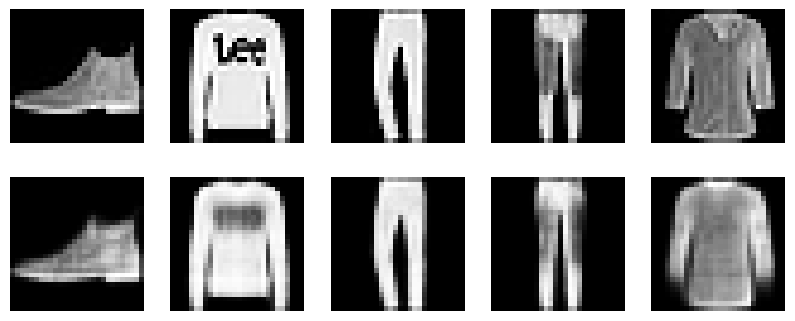

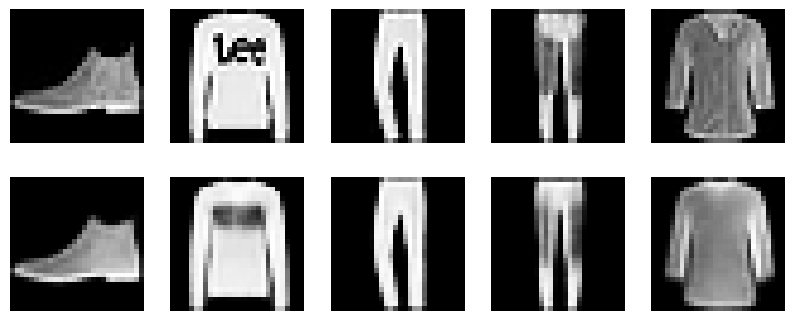

interactive(children=(FloatSlider(value=0.0, description='Z1', max=10.0, min=-10.0, step=0.5), FloatSlider(val…

In [ ]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on: {device}")

    transform = transforms.Compose([transforms.ToTensor()])
    train_ds = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
    test_ds = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


    fc_net = FCAutoEncoder().to(device)
    conv_net = ConvAutoEncoder().to(device)


    for model, path, name in [(fc_net, FC_WEIGHTS, "FC_AE"), (conv_net, CONV_WEIGHTS, "Conv_AE")]:
        if os.path.exists(path):
            print(f"\n[INFO] Found weights for {name}. Loading...")
            model.load_state_dict(torch.load(path, map_location=device))
        else:
            print(f"\n[INFO] No weights for {name}. Starting training...")
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
            train_model(model, train_loader, test_loader, nn.MSELoss(), optimizer, name, device)
            torch.save(model.state_dict(), path)
            print(f"Weights saved to {path}")
        
        save_reconstruction_plot(model, test_loader, device, f"results_{name}.png")


    interactive_decoder(conv_net, device)

if __name__ == "__main__":
    main()